In [2]:
from google.colab import files
uploaded = files.upload()  # Upload your CSV here

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("/content/Crop_recommendation.csv")

# Basic Inspection
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nTarget Distribution:\n", df['label'].value_counts())
df.describe(include='all')

Saving Crop_recommendation.csv to Crop_recommendation (1).csv
Shape: (2200, 8)

Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Data Types:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicates: 0

Target Distribution:
 label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100


,N,P,K,temperature,humidity,ph,rainfall,label
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rice
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,NaN
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,NaN
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,NaN
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,NaN
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,NaN
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,NaN


Null values after cleaning:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64
Duplicates: 0


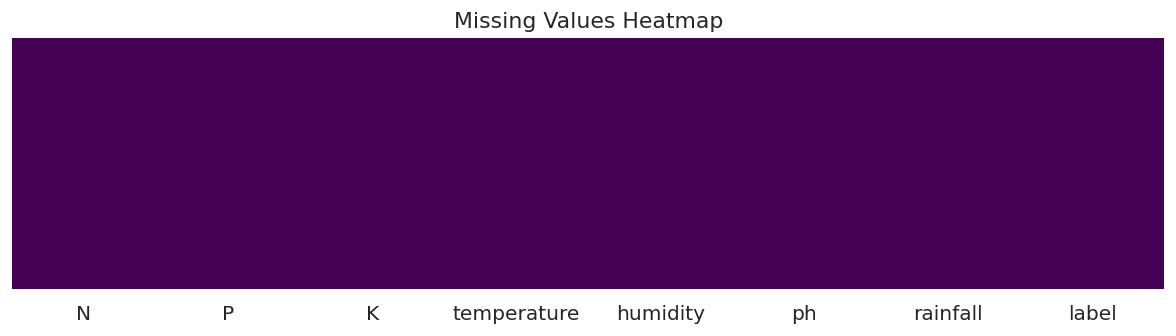

N: 0 outliers detected
P: 138 outliers detected
K: 200 outliers detected
temperature: 86 outliers detected
humidity: 30 outliers detected
ph: 57 outliers detected
rainfall: 100 outliers detected


In [4]:
# Standardize text columns
df['label'] = df['label'].str.strip().str.title()

# Confirm no nulls
print("Null values after cleaning:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Missing values heatmap
plt.figure(figsize=(10, 3))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig("01_missing_heatmap.png", bbox_inches='tight')
plt.show()

# Outlier detection using IQR
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers detected")

Train size: (1760, 8) | Test size: (440, 8)


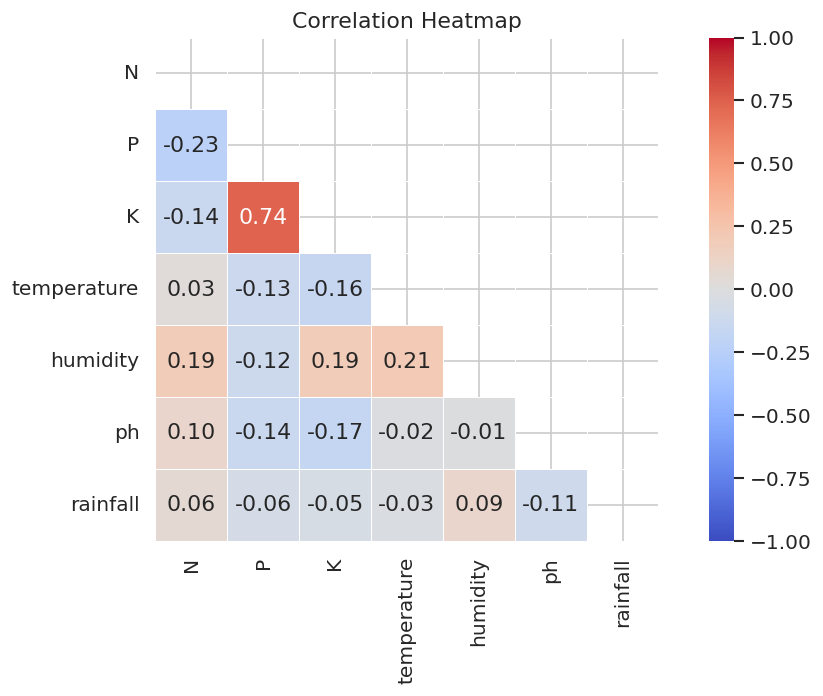

In [6]:
df_enc = df.copy()

# Create soil fertility score (engineered feature)
df_enc['fertility_score'] = (
df_enc['N'] + df_enc['P'] + df_enc['K']
    ) / 3

    # Label encode target
le = LabelEncoder()
df_enc['label_enc'] = le.fit_transform(df_enc['label'])

    # Scale numeric features
scaler = StandardScaler()
scale_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
df_enc[scale_cols] = scaler.fit_transform(df_enc[scale_cols])

    # Train/test split
X = df_enc.drop(columns=['label', 'label_enc'])
y = df_enc['label_enc']
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
        )
print("Train size:", X_train.shape, "| Test size:", X_test.shape)

        # Correlation Heatmap
plt.figure(figsize=(9, 6))
corr = df[['N','P','K','temperature','humidity','ph','rainfall']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("02_correlation_heatmap.png", bbox_inches='tight')
plt.show()


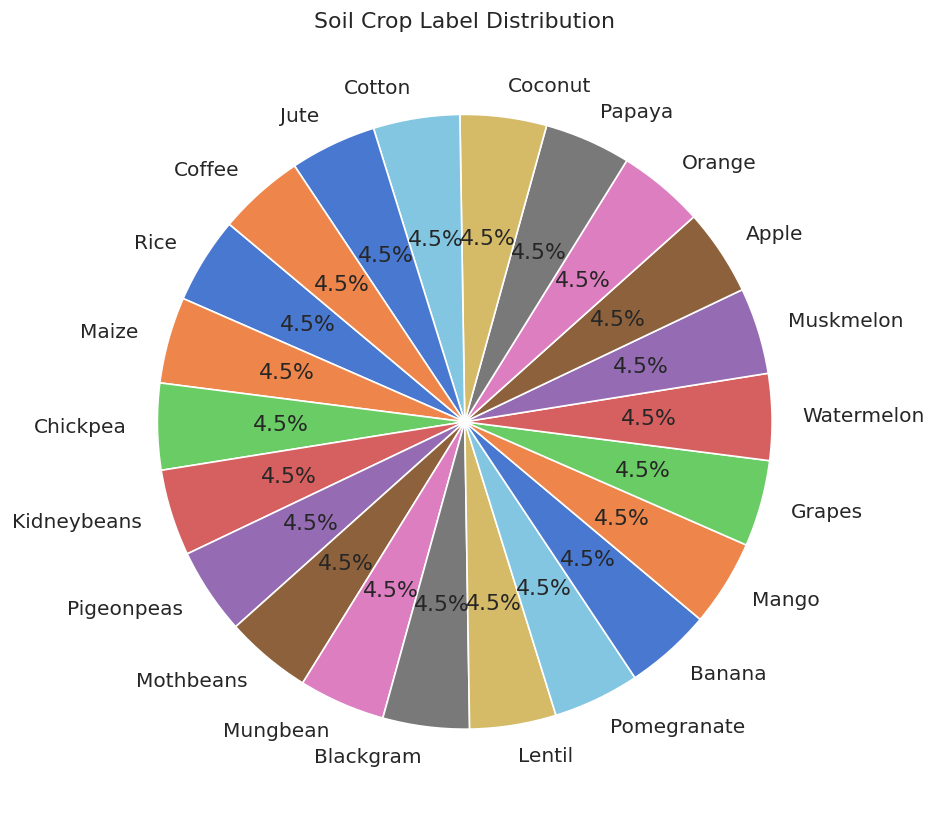

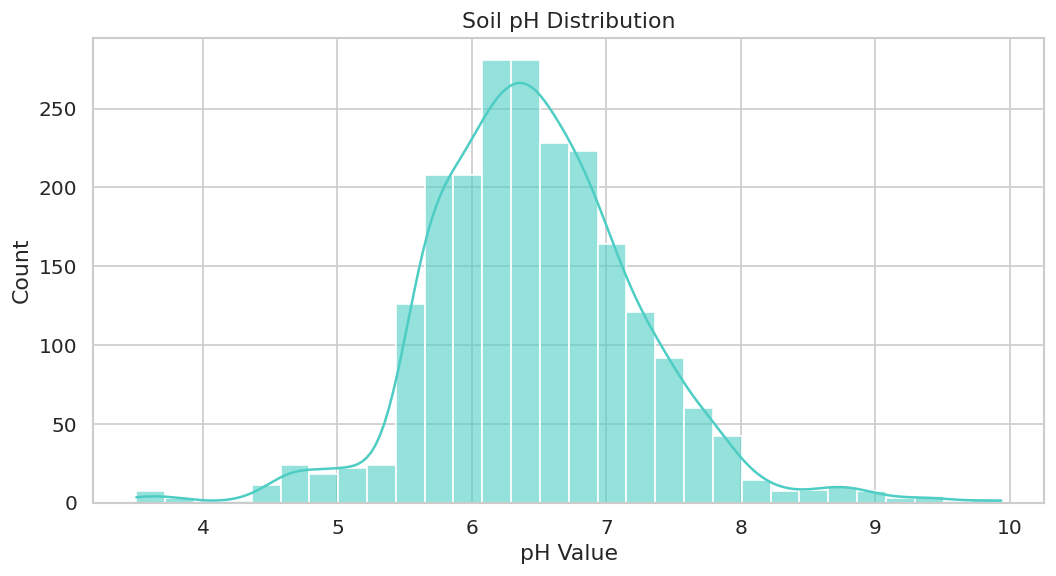

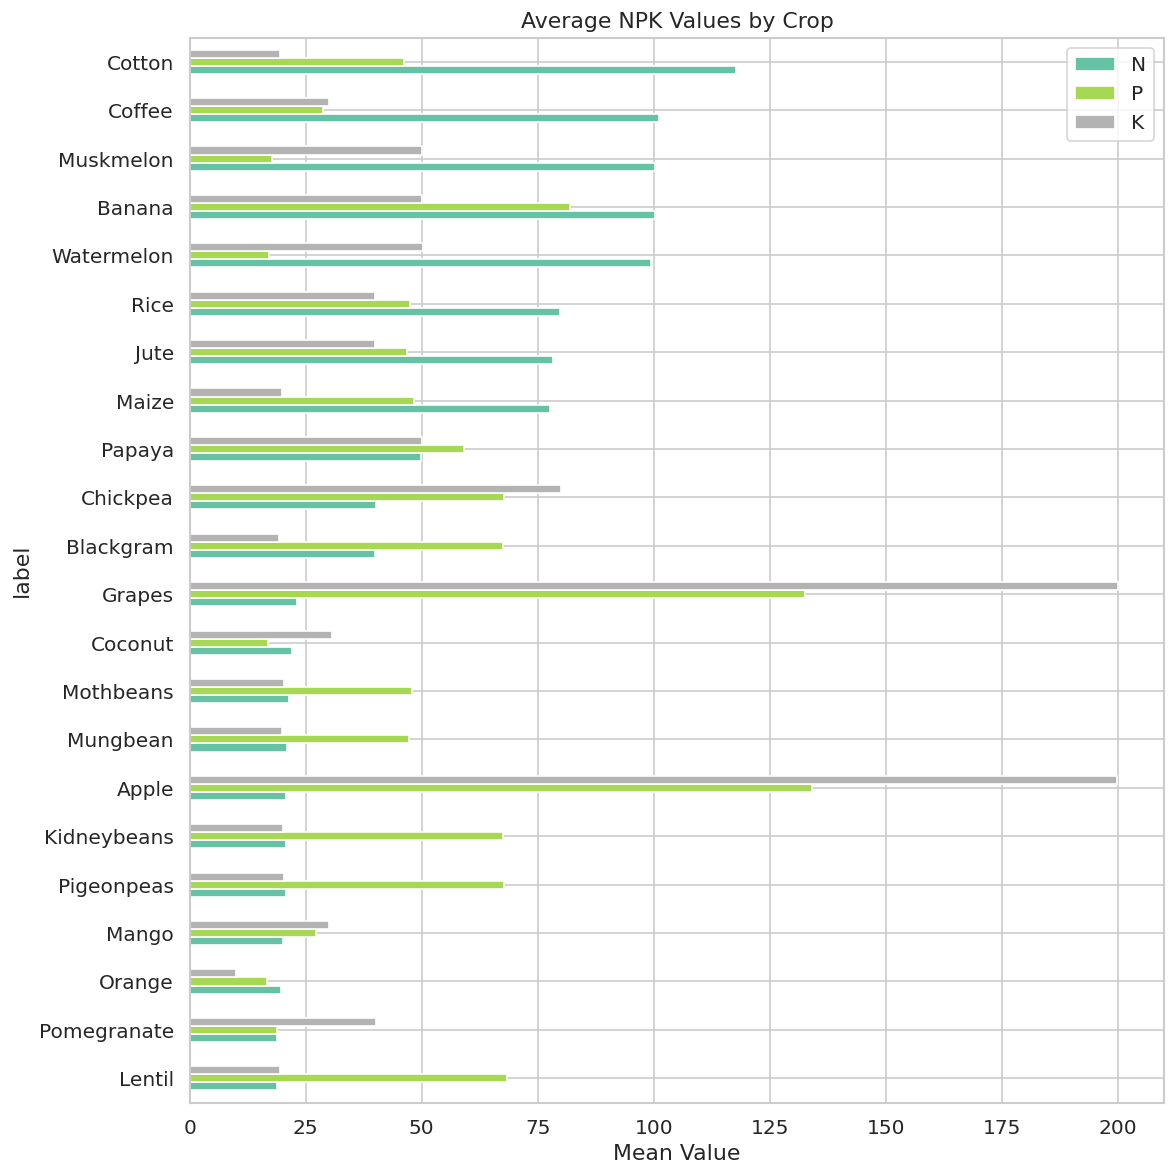

/tmp/ipykernel_3157/89398407.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['label'].isin(top6)], x='label', y='ph',


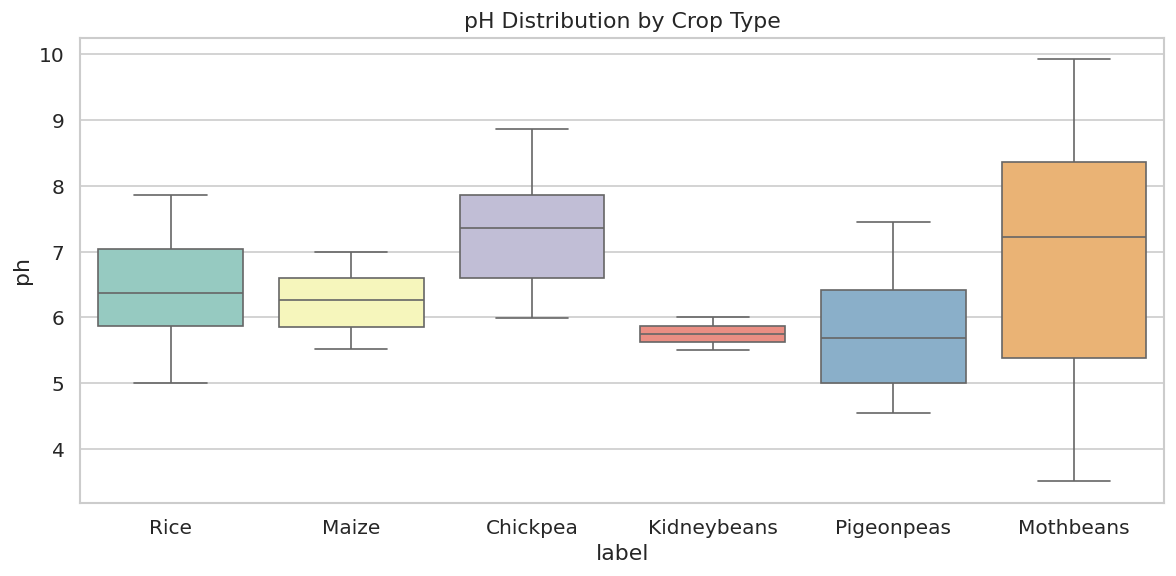

In [7]:
# 1. Target Distribution Pie Chart
sizes = df['label'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=sizes.index, autopct='%1.1f%%', startangle=140)
plt.title("Soil Crop Label Distribution")
plt.tight_layout()
plt.savefig("03_pie_overall.png", bbox_inches='tight')
plt.show()

# 2. pH Distribution by Fertility
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='ph', bins=30, kde=True, color='#4ECDC4', alpha=0.6)
plt.title("Soil pH Distribution")
plt.xlabel("pH Value")
plt.tight_layout()
plt.savefig("04_ph_dist.png", bbox_inches='tight')
plt.show()

# 3. NPK Bar Chart (mean values per crop)
npk_mean = df.groupby('label')[['N','P','K']].mean().sort_values('N')
npk_mean.plot(kind='barh', figsize=(10, 10), colormap='Set2')
plt.title("Average NPK Values by Crop")
plt.xlabel("Mean Value")
plt.tight_layout()
plt.savefig("05_npk_bar.png", bbox_inches='tight')
plt.show()

# 4. Boxplot - pH by top 6 crops
top6 = df['label'].value_counts().head(6).index
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df['label'].isin(top6)], x='label', y='ph',
palette='Set3')
plt.title("pH Distribution by Crop Type")
plt.tight_layout()
plt.savefig("06_boxplot_ph.png", bbox_inches='tight')
plt.show()